In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import mixed_precision
from tensorflow.keras.layers import Layer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import glob
import os
import csv
import shutil
import time


In [2]:

# Config
CONFIG = {
    "DATA_DIR": Path("TrainingData/indicators_data/processed/stocksData"),
    "FORECAST_DIR": Path("forecasts"),
    "CACHE_DIR": Path("cache"),
    "WINDOW_SIZE": 90,
    "TRAIN_VAL_FRAC": 0.8,
    "VAL_FRAC_WITHIN_TRAIN": 0.2,
    "MC_DROPOUT_SAMPLES": 25,
    "EXCLUDED_COLS": ["date", "Target_1d", "Target_1w", "Target_1m", "Target_6m"],
    "PROB_THRESHOLD": 0.7,
}

horizons = ["1d", "1w", "1m", "6m"]
horizon_days = [1, 5, 21, 126]

In [3]:
# Ensure dirs exist
CONFIG["FORECAST_DIR"].mkdir(exist_ok=True)
CONFIG["CACHE_DIR"].mkdir(exist_ok=True)

# Globals
scaler = StandardScaler()
feature_cols = None

In [4]:
# MC Dropout
class MCDropout(Dropout):
    def call(self, inputs, training=None):
        return super().call(inputs, training=True)

def mc_dropout_predict(model, X, n_samples=50):
    preds = np.array([model(X, training=True).numpy() for _ in range(n_samples)])
    return preds.mean(axis=0), preds.std(axis=0), preds

In [5]:
'''
Compute required return tresholds for each horizon to be considered a buy (2 sigma above average)
We can change this later to achieve higher returns but this is a good place to start for now.
'''
def compute_horizon_thresholds(df):
    thresholds = {}
    for h in ["1d", "1w", "1m", "6m"]:
        mu = df[f"Target_{h}"].mean()
        sig = df[f"Target_{h}"].std()
        thresholds[h] = mu + 2 * sig
    return thresholds

In [6]:
# Data processing helpers 
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df["Target_1d"] = np.log(df["close"].shift(-1) / df["close"])
    df["Target_1w"] = np.log(df["close"].shift(-5) / df["close"]) #Only 5 trading days in one week
    df["Target_1m"] = np.log(df["close"].shift(-21) / df["close"]) #Only 21 trading days in one month
    df["Target_6m"] = np.log(df["close"].shift(-126) / df["close"]) #Only 126 trading days in six months
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    return df

''' 
Training with overlapping horizons presents over fitting issues. To avoid this,
we can use a max-horizon step of 126 days (6 trading months). We will create
a separate process_stock for inference when it comes time to do the prediction.
This will give us daily predictions rather than a prediction every 126 days.
'''
def process_stock(csv_path: Path, for_training=True):
    df = pd.read_csv(csv_path, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
    df = add_features(df)

    # Compute thresholds
    thresholds = compute_horizon_thresholds(df)

    # Create binary classification targets
    for h in ["1d", "1w", "1m", "6m"]:
        df[f"Class_{h}"] = (df[f"Target_{h}"] > thresholds[h]).astype(int)
        
    if df.empty:
        return np.array([]), np.array([]), df, np.array([])

    global feature_cols
    for col in feature_cols:
        if col not in df.columns:
            df[col] = 0.0

    features_scaled = scaler.transform(df[feature_cols].values)
    dates = df["date"].values
    target = df[["Class_1d", "Class_1w", "Class_1m", "Class_6m"]].values if for_training else None

    X, y, y_dates = [], [], []
    window = CONFIG["WINDOW_SIZE"]
    max_horizon = max(horizon_days)#126 days,  6 trading months

    for i in range(window, len(features_scaled), max_horizon):
        X.append(features_scaled[i - window:i + 1])
        if for_training:
            y.append(target[i])
        y_dates.append(dates[i])

    return (
        np.array(X),
        np.array(y) if for_training else None,
        df,
        np.array(y_dates, dtype="datetime64[ns]"),
    )

In [7]:
def process_stock_for_inference(csv_path: Path):
    df = pd.read_csv(csv_path, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
    df = add_features(df)
    if df.empty:
        return np.array([]), np.array([]), df, np.array([])

    global feature_cols
    for col in feature_cols:
        if col not in df.columns:
            df[col] = 0.0

    features_scaled = scaler.transform(df[feature_cols].values)
    dates = df["date"].values
    target = df[["close"]].values

    X, x_dates = [], []
    window = CONFIG["WINDOW_SIZE"]
    max_horizon = 1 

    for i in range(window, len(features_scaled), max_horizon):
        X.append(features_scaled[i - window:i + 1])
        x_dates.append(dates[i])

    return (
        np.array(X),
        df.loc[window:, "close"].values[:len(X)],
        np.array(x_dates, dtype="datetime64[ns]"),
        df
    )

In [8]:
# Cache preprocessed stock
def cache_preprocessed_stock(csv_path: Path, train_cutoff, train_val_cutoff):
    stock_name = csv_path.stem
    print(f"Rebuilding cache for: {stock_name}")

    X, y, _, y_dates = process_stock(csv_path, for_training=True)
    if X.size == 0:
        for split in ["train", "val", "test"]:
            np.save(CONFIG["CACHE_DIR"] / f"{stock_name}_X_{split}.npy", np.array([]))
            np.save(CONFIG["CACHE_DIR"] / f"{stock_name}_y_{split}.npy", np.array([]))
        return

    y_dates = pd.to_datetime(y_dates)
    splits = {
        "train": y_dates < np.datetime64(train_cutoff),
        "val": (y_dates >= np.datetime64(train_cutoff)) & (y_dates < np.datetime64(train_val_cutoff)),
        "test": y_dates >= np.datetime64(train_val_cutoff),
    }
    for split, mask in splits.items():
        np.save(CONFIG["CACHE_DIR"] / f"{stock_name}_X_{split}.npy", X[mask])
        np.save(CONFIG["CACHE_DIR"] / f"{stock_name}_y_{split}.npy", y[mask])
        np.save(CONFIG["CACHE_DIR"] / f"{stock_name}_y_dates_{split}.npy", y_dates[mask])

    print(
        f"Cached {stock_name}: "
        + ", ".join([f"{s}={np.sum(m)}" for s, m in splits.items()])
    )

In [9]:
# Data generator
class StockDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, csv_paths, batch_size=512, split="train", shuffle=True, use_time_weights=True, decay_factor = 0.001):
        self.csv_paths = csv_paths
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.split = split
        self.use_time_weights = use_time_weights
        self.decay_factor = decay_factor
        self.windows = []
        self.stock_names = [Path(p).stem for p in csv_paths]
        self._prepare_indices()
        self.on_epoch_end()

    def _prepare_indices(self):
        self.windows = []
        self.lengths = {}
        self.date_arrays = {}
        for stock_name in self.stock_names:
            X_path = CONFIG["CACHE_DIR"] / f"{stock_name}_X_{self.split}.npy"
            y_path = CONFIG["CACHE_DIR"] / f"{stock_name}_y_{self.split}.npy"
            date_path = CONFIG["CACHE_DIR"] / f"{stock_name}_y_dates_{self.split}.npy"
            if not X_path.exists():
                n_windows = 0
            else:
                X = np.load(X_path, mmap_mode="r")
                n_windows = len(X)
                if date_path.exists():
                    self.date_arrays[stock_name] = np.load(date_path, allow_pickle=True)
            self.lengths[stock_name] = n_windows
            for i in range(n_windows):
                self.windows.append((stock_name, i))
        self.indices = np.arange(len(self.windows))

    def __len__(self):
        return int(np.ceil(len(self.windows) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        X_batch, y_batch, weights_batch = [], [], []
        cache = {}
        for bi in batch_indices:
            stock_name, win_idx = self.windows[bi]
            if stock_name not in cache:
                X = np.load(CONFIG["CACHE_DIR"] / f"{stock_name}_X_{self.split}.npy", mmap_mode="r")
                y = np.load(CONFIG["CACHE_DIR"] / f"{stock_name}_y_{self.split}.npy", mmap_mode="r")
                cache[stock_name] = (X, y)
            X_arr, y_arr = cache[stock_name]
            X_batch.append(X_arr[win_idx])
            y_batch.append(y_arr[win_idx])

            if self.use_time_weights and stock_name in self.date_arrays:
                dates = self.date_arrays[stock_name]
                date = pd.to_datetime(dates[win_idx])
                #Give more weight to recent dates now
                date_ago = (pd.Timestamp.now() - date).days
                weights_batch.append(np.exp(-self.decay_factor * date_ago))
            else:
                weights_batch.append(1.0)

        return (np.array(X_batch, dtype=np.float32), 
                np.array(y_batch, dtype=np.float32),
                np.array(weights_batch, dtype=np.float32))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [10]:
def make_forecast(model, X, dates, closes, horizons, horizon_days):
    y_pred_mean, y_pred_std, _ = mc_dropout_predict(model, X, n_samples=CONFIG["MC_DROPOUT_SAMPLES"])
    df_dict = {"Date": dates, "Close": closes}

    for i, h in enumerate(horizons):
        df_dict[f"Pred_Prob_{h}"] = y_pred_mean[:, i]
        df_dict[f"Pred_Prob_Std_{h}"] = y_pred_std[:, i]   

    forecasting_df = pd.DataFrame(df_dict)
    return forecasting_df

all_csvs = sorted(glob.glob(str(CONFIG["DATA_DIR"] / "*.csv")))
print(f"Found {len(all_csvs)} stocks")

Found 1688 stocks


In [11]:
# Determine global cutoffs & fit scaler
global_min_date, global_max_date = None, None
scaler_inputs = []
feature_cols = None

for csv_path in all_csvs:
    df_tmp = pd.read_csv(csv_path, parse_dates=["date"])
    if global_min_date is None or df_tmp["date"].min() < global_min_date:
        global_min_date = df_tmp["date"].min()
    if global_max_date is None or df_tmp["date"].max() > global_max_date:
        global_max_date = df_tmp["date"].max()

train_val_cutoff = global_min_date + (global_max_date - global_min_date) * CONFIG["TRAIN_VAL_FRAC"]
train_cutoff = global_min_date + (train_val_cutoff - global_min_date) * (1 - CONFIG["VAL_FRAC_WITHIN_TRAIN"])

for csv_path in all_csvs:
    df = pd.read_csv(csv_path, parse_dates=["date"]).sort_values("date").dropna()
    df = add_features(df)
    if df.empty:
        continue
    feat_cols = [c for c in df.columns if c not in CONFIG["EXCLUDED_COLS"]]
    if feature_cols is None:
        feature_cols = feat_cols
    train_rows = df[df["date"] < train_cutoff]
    if len(train_rows) > 0:
        scaler_inputs.append(train_rows[feat_cols].values)

X = np.vstack(scaler_inputs)
X = np.nan_to_num(X, nan=0.0, posinf=1e6, neginf=-1e6)
scaler.fit(X)
print("Fitted scaler. feature_cols:", feature_cols)


Fitted scaler. feature_cols: ['close', 'YesterdayClose', 'YesterdayOpenLogR', 'YesterdayHighLogR', 'YesterdayLowLogR', 'YesterdayVolumeLogR', 'YesterdayCloseLogR', 'MA10', 'MA20', 'MA30', 'DayOfWeek', 'DayOfMonth', 'MonthNumber', 'EMA10', 'EMA30', 'RSI', 'MACD', 'MACD_Signal', 'BollingerUpper', 'BollingerLower', 'Volatility_10', 'Volatility_20', 'Volatility_30', 'OBV', 'ZScore', 'insider_shares', 'insider_amount', 'insider_buy_flag', 'sentiment', 'num_articles', 'overnight_gap', 'abnormal_vol', 'volatility_5d', 'volatility_20d', 'momentum_5d', 'momentum_20d', 'skew_5d', 'intraday_range', 'sentiment_change']


In [12]:
time.sleep(5)
# Cache all data 
if CONFIG["CACHE_DIR"].exists():
    shutil.rmtree(CONFIG["CACHE_DIR"])
CONFIG["CACHE_DIR"].mkdir(exist_ok=True)

print("Caching all preprocessed stock data...")
for csv_path in all_csvs:
    cache_preprocessed_stock(Path(csv_path), train_cutoff, train_val_cutoff)
print("Done caching.")

Caching all preprocessed stock data...
Rebuilding cache for: AACG_daily_processed
Cached AACG_daily_processed: train=15, val=9, test=9
Rebuilding cache for: AAL_daily_processed
Cached AAL_daily_processed: train=21, val=8, test=10
Rebuilding cache for: AAME_daily_processed
Cached AAME_daily_processed: train=28, val=8, test=9
Rebuilding cache for: AAMI_daily_processed
Cached AAMI_daily_processed: train=0, val=5, test=9
Rebuilding cache for: AAOI_daily_processed
Cached AAOI_daily_processed: train=5, val=9, test=9
Rebuilding cache for: AAON_daily_processed
Cached AAON_daily_processed: train=33, val=8, test=10
Rebuilding cache for: AAPL_daily_processed
Cached AAPL_daily_processed: train=33, val=8, test=10
Rebuilding cache for: AAP_daily_processed
Cached AAP_daily_processed: train=29, val=8, test=9
Rebuilding cache for: AAT_daily_processed
Cached AAT_daily_processed: train=11, val=8, test=9
Rebuilding cache for: AA_daily_processed
Cached AA_daily_processed: train=0, val=7, test=10
Rebuilding

In [13]:
class Attention(Layer):
    def __init__(self):
        super(Attention, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1),
                                 initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1),
                                 initializer="zeros")        
        super().build(input_shape)

    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)  # attention weights
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

In [14]:
# Data generators
train_gen = StockDataGenerator(all_csvs, batch_size=128, split="train", shuffle=True, use_time_weights=False, decay_factor=0.002)
val_gen = StockDataGenerator(all_csvs, batch_size=128, split="val", shuffle=False)

In [15]:
# Actual training with the weights now
def generator_with_weights(gen):
    for X, y, w in gen:
        yield X, y, w

train_dataset = tf.data.Dataset.from_generator(
    lambda: generator_with_weights(train_gen),
    output_signature=(
        tf.TensorSpec(shape=(None, CONFIG["WINDOW_SIZE"] + 1, len(feature_cols)), dtype=tf.float32),
        tf.TensorSpec(shape=(None, 4), dtype=tf.float32),
        tf.TensorSpec(shape=(None,), dtype=tf.float32),
    )
)

val_dataset = tf.data.Dataset.from_generator(
    lambda: generator_with_weights(val_gen),
    output_signature=(
        tf.TensorSpec(shape=(None, CONFIG["WINDOW_SIZE"] + 1, len(feature_cols)), dtype=tf.float32),
        tf.TensorSpec(shape=(None, 4), dtype=tf.float32),
        tf.TensorSpec(shape=(None,), dtype=tf.float32),
    )
)

##### **AUC (Area Under the ROC Curve)**

AUC measures how well the model **ranks positive outcomes higher than negative ones**.  
In other words, if you randomly pick one example where the stock *did exceed* the target threshold  
and one where it *didn’t*, AUC tells you how often the model assigns a higher probability  
to the correct (positive) case.

This is extremely important for my forecasting code because the backtest selects trades by  
**choosing the horizon with the highest predicted probability** each day.  
The model is not judged by whether its prediction crosses a threshold like 0.5 -  
it is judged by how well it *ranks* stronger opportunities above weaker ones.  

**AUC scale:**

- **0.5** → Random guessing (no predictive power)  
- **0.6** → Slightly better than random (weak but may still be usable in trading)  
- **0.8** → Good (model reliably separates strong opportunities from weak ones)  
- **1.0** → Perfect separation (unrealistic for financial markets)

Higher AUC means the model is better at identifying which future returns are likely  
to exceed the "(mean + 2sigma)" threshold - which directly improves the decision-making in my backtest.


Epoch 1/500
229/229 [==============================] - 26s 104ms/step - loss: 0.1439 - auc: 0.6510 - val_loss: 0.0090 - val_auc: 0.6872
Epoch 2/500
229/229 [==============================] - 23s 100ms/step - loss: 0.0962 - auc: 0.7616 - val_loss: 0.0087 - val_auc: 0.7345
Epoch 3/500
229/229 [==============================] - 23s 101ms/step - loss: 0.0936 - auc: 0.7824 - val_loss: 0.0088 - val_auc: 0.7292
Epoch 4/500
229/229 [==============================] - 25s 109ms/step - loss: 0.0919 - auc: 0.7895 - val_loss: 0.0087 - val_auc: 0.7422
Epoch 5/500
229/229 [==============================] - 24s 105ms/step - loss: 0.0913 - auc: 0.7973 - val_loss: 0.0086 - val_auc: 0.7558
Epoch 6/500
229/229 [==============================] - 23s 99ms/step - loss: 0.0910 - auc: 0.7994 - val_loss: 0.0088 - val_auc: 0.7405
Epoch 7/500
229/229 [==============================] - 23s 101ms/step - loss: 0.0896 - auc: 0.8054 - val_loss: 0.0088 - val_auc: 0.7367
Epoch 8/500
229/229 [============================

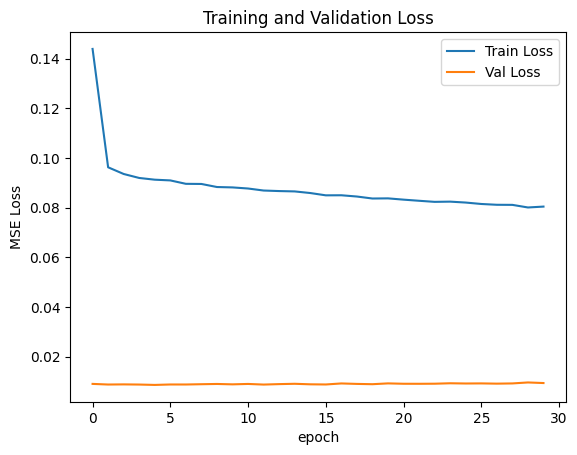

In [18]:
from tensorflow.keras.metrics import AUC
n_features = len(feature_cols)
model = Sequential([
    Conv1D(32, kernel_size=3, activation="relu", 
           input_shape=(CONFIG["WINDOW_SIZE"] + 1, n_features)),
    BatchNormalization(),
    MCDropout(0.3),
    LSTM(64, return_sequences=False), 
    MCDropout(0.3),
    Dense(32, activation="relu"),
    Dense(4, activation="sigmoid") #Four time horizon predictions as output
])

early_stop = EarlyStopping(
    patience = 25,
    monitor = "val_loss",
    restore_best_weights = True,
    mode = "min",
)

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=[AUC(name="auc")])
history = model.fit(train_gen, validation_data=val_gen, callbacks=[early_stop],epochs=500)
#history = model.fit(train_gen, validation_data=val_gen,epochs=2)

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")
plt.legend(); plt.show()

In [19]:
from sklearn.metrics import mean_squared_error

def feature_importance(model, X_val, y_val, feature_names):
    base_preds = model.predict(X_val)
    base_loss = mean_squared_error(y_val, base_preds)
    importances = []

    for i, col in enumerate(feature_names):
        X_val_permuted = X_val.copy()
        np.random.shuffle(X_val_permuted[:, :, i])
        preds = model.predict(X_val_permuted)
        loss = mean_squared_error(y_val, preds)
        importances.append(loss - base_loss)

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances,
    }).sort_values("Importance", ascending=False)

    return importance_df

4/4 [==============================] - 0s 10ms/step


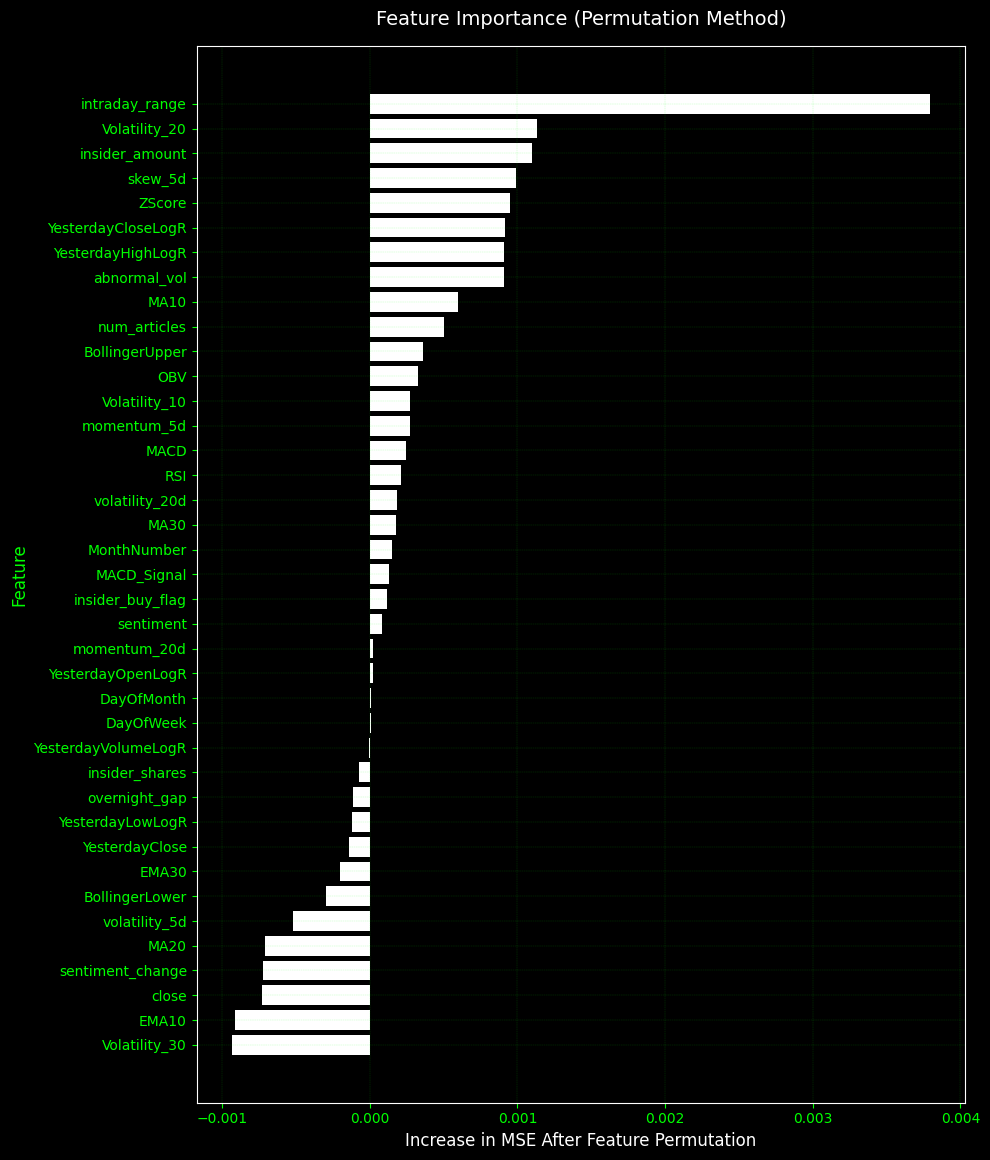

In [20]:
batch = val_gen[0]
if isinstance(batch, tuple):
    if len(batch) == 2:
        X_val, y_val = batch
    elif len(batch) == 3:
        X_val, y_val, _ = batch  # ignore sample weights
    else:
        raise ValueError(f"Unexpected number of outputs: {len(batch)}")
else:
    raise ValueError("val_gen[0] did not return a tuple.")
importance_df = feature_importance(model, X_val, y_val, feature_cols)

#Plot
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, max(6, len(feature_cols) * 0.3)))  # dynamically scale height

ax.barh(importance_df["Feature"], importance_df["Importance"], color="white", linewidth=1.2)
ax.set_xlabel("Increase in MSE After Feature Permutation", fontsize=12)
ax.set_ylabel("Feature", color="lime", fontsize=12)
ax.set_title("Feature Importance (Permutation Method)", fontsize=14, pad=15)

# Customize tick labels
ax.tick_params(axis='x', colors='lime')
ax.tick_params(axis='y', colors='lime')

# Optional grid styling
ax.grid(color='lime', linestyle='--', linewidth=0.3, alpha=0.3)

# Flip the order (so most important features at top)
plt.gca().invert_yaxis()

plt.tight_layout()
output_path = CONFIG["FORECAST_DIR"] / "feature_importance.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="black")
plt.show()
# Save as high-quality PNG


In [21]:
# Forecasting 
for file in glob.glob(str(CONFIG["FORECAST_DIR"] / "*.csv")):
    os.remove(file)

print("Generating forecasts...")

for csv_path in all_csvs:
    stock_name = Path(csv_path).stem

    X_all, closes, pred_dates, df = process_stock_for_inference(Path(csv_path))

    # Skip if nothing to forecast
    if X_all.size == 0:
        continue

    # Create forecast dataframe
    forecast_df = make_forecast(
        model=model,
        X=X_all,
        dates=pred_dates,
        closes=closes,
        horizons=horizons,
        horizon_days=horizon_days
    )

    forecast_df.to_csv(CONFIG["FORECAST_DIR"] / f"{stock_name}_forecast.csv", index=False)
    print("Saved:", stock_name)

print("Done.")

Generating forecasts...
Saved: AACG_daily_processed
Saved: AAL_daily_processed
Saved: AAME_daily_processed
Saved: AAMI_daily_processed
Saved: AAOI_daily_processed
Saved: AAON_daily_processed
Saved: AAPL_daily_processed
Saved: AAP_daily_processed
Saved: AAT_daily_processed
Saved: AA_daily_processed
Saved: ABBV_daily_processed
Saved: ABCB_daily_processed
Saved: ABCL_daily_processed
Saved: ABEO_daily_processed
Saved: ABEV_daily_processed
Saved: ABG_daily_processed
Saved: ABL_daily_processed
Saved: ABM_daily_processed
Saved: ABNB_daily_processed
Saved: ABOS_daily_processed
Saved: ABR_daily_processed
Saved: ABSI_daily_processed
Saved: ABTS_daily_processed
Saved: ABT_daily_processed
Saved: ABUS_daily_processed
Saved: ABVC_daily_processed
Saved: AB_daily_processed
Saved: ACAD_daily_processed
Saved: ACA_daily_processed
Saved: ACB_daily_processed
Saved: ACCO_daily_processed
Saved: ACCS_daily_processed
Saved: ACEL_daily_processed
Saved: ACET_daily_processed
Saved: ACGLN_daily_processed
Saved: AC

MemoryError: Unable to allocate 171. MiB for an array with shape (6314, 91, 39) and data type float64